In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import cufflinks as cf
import plotly.express as px
%matplotlib inline

from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
cf.go_offline()

In [17]:
import plotly
print(plotly.__version__)

6.7.0


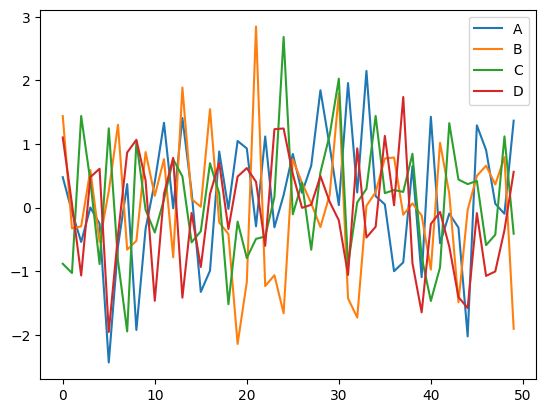

In [3]:
arr_1 = np.random.randn(50,4)
df_1 = pd.DataFrame(arr_1, columns=['A', 'B', 'C', 'D'])
df_1.head()
df_1.plot();

## Line Plots

In [4]:
import plotly.graph_objects as go
df_stocks = px.data.stocks()
px.line(df_stocks, x = "date", y = "GOOG", labels={'date': 'Date', 'GOOG': 'Price'})

px.line(df_stocks, x = 'date', y = ['GOOG', 'AAPL'], labels = {'date': 'Date', 'y': 'Price'}, title='Apple vs Google')

fig = go.Figure()
fig.add_trace(go.Scatter(x = df_stocks.date, y = df_stocks.AAPL, mode = 'lines', name = 'Apple'))
fig.add_trace(go.Scatter(x = df_stocks.date, y = df_stocks.AMZN, mode = 'lines+markers', name = 'Amazon'))
fig.add_trace(go.Scatter(x = df_stocks.date, y = df_stocks.GOOG, mode = 'lines+markers', name = 'Google', line = dict(color = 'firebrick', width = 2, dash = 'dashdot')))

# fig.update_layout(title = 'Stock Price Data 2018 - 2020', xaxis_title = 'Price', yaxis_title = 'Date')

fig.update_layout(xaxis = dict(showline = True, showgrid = False, showticklabels = True, linecolor = 'rgb(204, 204, 204)', linewidth = 2, ticks = 'outside', tickfont = dict(family = 'Arial', size = 12, color = 'rgb(82,82,82)')),
                  yaxis = dict(showgrid = False, zeroline = False, showline = False, showticklabels = False),
                  autosize = False, 
                  margin = dict(
                    autoexpand = False, l = 100, r = 20, t = 110
                  ),
                  showlegend = False, plot_bgcolor = 'white')


## Bar Charts

In [5]:
df_us = px.data.gapminder().query("country == 'United States'")

In [6]:
px.bar(df_us, x = 'year', y = 'pop')

In [7]:
# Stacked bar
df_tips = px.data.tips()
px.bar(df_tips, x = 'day', y = 'tip', color = 'sex', title = 'Tips by Sex on Each Day', labels = {'tip': 'Tip Amount', 'day': "Day of the week"})

In [8]:
px.bar(df_tips, x = 'sex', y = 'total_bill', color = 'smoker', barmode = 'group')

In [9]:
df_europe = px.data.gapminder().query("continent == 'Europe' and year == 2007 and pop > 2.e6")
fig = px.bar(df_europe, y = 'pop', x = 'country', text = 'pop', color = 'country')

fig.update_traces(texttemplate = '%{text:.2s}', textposition = 'outside')
fig.update_layout(uniformtext_minsize = 8)
fig.update_layout(xaxis_tickangle = -45)

fig

## Scatter Plots

In [12]:
df_iris = px.data.iris()
px.scatter(df_iris, 
           x = 'sepal_width', 
           y = 'sepal_length', 
           color = 'species',
           size = 'petal_length',
           hover_data = ['petal_width'])

In [18]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x = df_iris.sepal_width,
    y = df_iris.sepal_length,
    mode = 'markers',
    marker_color = df_iris.sepal_width,
    text = df_iris.species,
    marker = dict(showscale = True)))
fig.update_traces(
    marker_line_width = 2,
    marker_size = 10
)

fig = go.Figure(data = go.Scattergl(
    x = np.random.randn(10000),
    y = np.random.randn(10000),
    mode = 'markers',
    marker = dict(color = np.random.randn(10000),
    colorscale = 'Viridis',
    line_width = 1)
))

fig.show()

## Pie Charts

In [20]:
df_asia = px.data.gapminder().query('year == 2007').query('continent == "Asia"')

In [21]:
px.pie(df_asia,
       values = 'pop',
       names = 'country',
       title = 'Population of Asian Continent',
       color_discrete_sequence = px.colors.sequential.RdBu)

In [25]:
colors = ['blue','green', 'black', 'purple', 'red', 'brown']
fig = go.Figure(
    data = [go.Pie(labels = ['Water', 'Grass', 'Normal', 'Psychic', 'Fire', 'Ground',],
                   values = [110, 90, 80, 80, 70, 60])]
)

fig.update_traces(
    hoverinfo = 'label + percent',
    textfont_size = 20,
    textinfo = 'label + percent',
    pull = [0.1, 0, 0.2, 0, 0],
    marker = dict(
        colors = colors,
        line = dict(
            color = 'white',
            width = 2
        )
    )
)
fig.show()

## Histogram

In [ ]:
dice_1 = np.random.randint(1, 7, 50000)
dice_2 = np.random.randint(1, 7, 50000)

dice_sum = dice_1 + dice_2

fig = px.histogram(
    dice_sum,
    nbins = 11,
    labels = {'value': 'Dice Roll'},
    title = '5000 dice roll histogram',
    marginal = 'violin',
    color_discrete_sequence = ['green']
)

fig.update_layout(
    xaxis_title_text = 'Dice Roll',
    yaxis_title_text = 'Dice Sum',
    bargap = 0.2,
    showlegend = False
)

fig

In [28]:
# stack histogram
df_tips = px.data.tips()
px.histogram(
    df_tips,
    x = 'total_bill',
    color = 'sex'
)

## Box Plots